Importing The Dependencies

In [2]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [10]:
# loading the dataset to a Pandas DataFrame
credit_card_data = pd.read_csv('/creditcard.csv')

In [13]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [14]:
# first 5 rows of the dataset
credit_card_data.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


Importing the Dependencies

In [15]:
credit_card_data.tail()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0
284806,172792.0,-0.533413,-0.189733,0.703337,-0.506271,-0.012546,-0.649617,1.577006,-0.414650,0.486180,...,0.261057,0.643078,0.376777,0.008797,-0.473649,-0.818267,-0.002415,0.013649,217.00,0


In [16]:
# dataset informations
credit_card_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [17]:
# checking the number of missing values in each column
credit_card_data.isnull().sum()

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


In [18]:
# distribution of legit transactions & fraudulent transactions
credit_card_data['Class'].value_counts()

,count
Class,
0,284315
1,492


This Dataset is highly unblanced

0 --> Normal Transaction

1 --> fraudulent transaction

In [19]:
# separating the data for analysis
legit = credit_card_data[credit_card_data.Class == 0]
fraud = credit_card_data[credit_card_data.Class == 1]

In [20]:
print(legit.shape)
print(fraud.shape)

(284315, 31)
(492, 31)


In [21]:
# statistical measures of the data
legit.Amount.describe()

,Amount
count,284315.000000
mean,88.291022
std,250.105092
min,0.000000
25%,5.650000
50%,22.000000
75%,77.050000
max,25691.160000


In [22]:
fraud.Amount.describe()

,Amount
count,492.000000
mean,122.211321
std,256.683288
min,0.000000
25%,1.000000
50%,9.250000
75%,105.890000
max,2125.870000


In [ ]:
# compare the values for both transactions
credit_card_data.groupby('Class').mean()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
Class,,,,,,,,,,,,,,,,,,,,,
0.0,5921.607697,-0.235577,0.266833,0.934388,0.239735,-0.041743,0.140925,-0.057661,-0.069971,0.813003,...,0.026103,-0.055139,-0.152043,-0.033460,0.023142,0.087567,0.107554,0.003624,0.001701,62.919501
1.0,9063.157895,-1.796662,3.810809,-6.415255,5.618146,-1.247563,-2.111328,-3.777261,1.150469,-2.276505,...,0.467700,0.741934,-0.164628,-0.024469,-0.371142,0.018063,0.310646,0.525443,0.355663,75.730526


Under-Sampling

Build a sample dataset containing similar distribution of normal transactions and Fraudulent Transactions

Number of Fraudulent Transactions --> 492

In [ ]:
legit_sample = legit.sample(n=492)

Concatenating two DataFrames

In [ ]:
new_dataset = pd.concat([legit_sample, fraud], axis=0)

In [ ]:
new_dataset.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
8007,10993,1.297480,-0.102322,0.327878,-0.102079,-0.142966,0.249701,-0.584281,0.043935,1.603996,...,-0.105332,-0.084089,-0.189624,-0.981947,0.347155,1.096798,-0.096590,-0.018294,15.95,0.0
7366,9919,-3.816680,3.869382,-0.551762,2.723526,-1.133908,0.864880,-1.908397,-1.324138,-0.306180,...,2.663820,-2.229707,0.682072,-0.180754,0.316739,-0.038430,-0.043139,-0.027817,20.69,0.0
1604,1248,-0.666314,0.737027,2.592203,0.703088,-0.335151,0.374667,-0.042351,-0.739707,0.429482,...,0.774186,0.190429,-0.034757,0.392249,-0.160191,-0.462660,0.031044,-0.142552,9.99,0.0
3398,2922,-0.992595,0.399507,1.052572,0.574846,1.308590,0.018082,0.817578,0.078251,-1.179087,...,-0.271119,-1.182435,-0.016922,-1.028080,0.428775,-0.547555,0.008129,0.072269,83.08,0.0
3127,2705,-0.500574,0.638609,2.142909,1.136488,0.477066,0.402103,1.073177,-0.468665,0.007784,...,-0.102252,0.341616,-0.250779,0.219864,-0.060039,-0.323479,-0.595718,-0.584530,17.61,0.0


In [ ]:
new_dataset.tail()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
9035,12597,-2.589617,7.016714,-13.705407,10.343228,-2.954461,-3.055116,-9.301289,3.349573,-5.654212,...,1.887738,0.333998,0.287659,-1.186406,-0.690273,0.631704,1.934221,0.789687,1.0,1.0
9179,13126,-2.880042,5.225442,-11.063330,6.689951,-5.759924,-2.244031,-11.199975,4.014722,-3.429304,...,2.002883,0.351102,0.795255,-0.778379,-1.646815,0.487539,1.427713,0.583172,1.0,1.0
9252,13323,-5.454362,8.287421,-12.752811,8.594342,-3.106002,-3.179949,-9.252794,4.245062,-6.329801,...,1.846165,-0.267172,-0.310804,-1.201685,1.352176,0.608425,1.574715,0.808725,1.0,1.0
9487,14073,-4.153014,8.204797,-15.031714,10.330100,-3.994426,-3.250013,-10.415698,4.620804,-5.711248,...,1.976988,0.256510,0.485908,-1.198821,-0.526567,0.634874,1.627209,0.723235,1.0,1.0
9509,14152,-4.710529,8.636214,-15.496222,10.313349,-4.351341,-3.322689,-10.788373,5.060381,-5.689311,...,1.990545,0.223785,0.554408,-1.204042,-0.450685,0.641836,1.605958,0.721644,1.0,1.0


In [ ]:
new_dataset['Class'].value_counts()

Class
0.0    492
1.0     38
Name: count, dtype: int64

In [ ]:
new_dataset.groupby('Class').mean()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
Class,,,,,,,,,,,,,,,,,,,,,
0.0,5682.260163,-0.265311,0.264712,0.988217,0.279410,-0.075070,0.047980,0.007052,-0.044035,0.724841,...,0.039231,-0.090585,-0.150797,-0.030644,-0.006313,0.081096,0.135601,0.015863,0.024508,64.866240
1.0,9063.157895,-1.796662,3.810809,-6.415255,5.618146,-1.247563,-2.111328,-3.777261,1.150469,-2.276505,...,0.467700,0.741934,-0.164628,-0.024469,-0.371142,0.018063,0.310646,0.525443,0.355663,75.730526


Splitting the data into Features & Targets

In [ ]:
X = new_dataset.drop(columns='Class', axis=1)
Y = new_dataset['Class']

In [ ]:
print(X)

       Time        V1        V2         V3         V4        V5        V6  \
8007  10993  1.297480 -0.102322   0.327878  -0.102079 -0.142966  0.249701   
7366   9919 -3.816680  3.869382  -0.551762   2.723526 -1.133908  0.864880   
1604   1248 -0.666314  0.737027   2.592203   0.703088 -0.335151  0.374667   
3398   2922 -0.992595  0.399507   1.052572   0.574846  1.308590  0.018082   
3127   2705 -0.500574  0.638609   2.142909   1.136488  0.477066  0.402103   
...     ...       ...       ...        ...        ...       ...       ...   
9035  12597 -2.589617  7.016714 -13.705407  10.343228 -2.954461 -3.055116   
9179  13126 -2.880042  5.225442 -11.063330   6.689951 -5.759924 -2.244031   
9252  13323 -5.454362  8.287421 -12.752811   8.594342 -3.106002 -3.179949   
9487  14073 -4.153014  8.204797 -15.031714  10.330100 -3.994426 -3.250013   
9509  14152 -4.710529  8.636214 -15.496222  10.313349 -4.351341 -3.322689   

             V7        V8        V9  ...       V20       V21       V22  \
8

In [ ]:
print(Y)

8007    0.0
7366    0.0
1604    0.0
3398    0.0
3127    0.0
       ... 
9035    1.0
9179    1.0
9252    1.0
9487    1.0
9509    1.0
Name: Class, Length: 530, dtype: float64


Split the data into Training data & Testing Data

In [ ]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, stratify=Y, random_state=2)

In [ ]:
print(X.shape, X_train.shape, X_test.shape)

(530, 30) (424, 30) (106, 30)


In [ ]:
model = LogisticRegression()

In [ ]:
# training the Logistic Regression Model with Training Data
model.fit(X_train, Y_train)

/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

Model Evaluation

Accuracy Score

In [ ]:
# accuracy on training data
X_train_prediction = model.predict(X_train)
training_data_accuracy = accuracy_score(X_train_prediction, Y_train)

In [ ]:
print('Accuracy on Training data : ', training_data_accuracy)

Accuracy on Training data :  1.0


In [ ]:
# accuracy on test data
X_test_prediction = model.predict(X_test)
test_data_accuracy = accuracy_score(X_test_prediction, Y_test)

In [ ]:
print('Accuracy score on Test Data : ', test_data_accuracy)

Accuracy score on Test Data :  1.0


Graph for Dataset

In [ ]:
import seaborn as sns
import pandas as pd

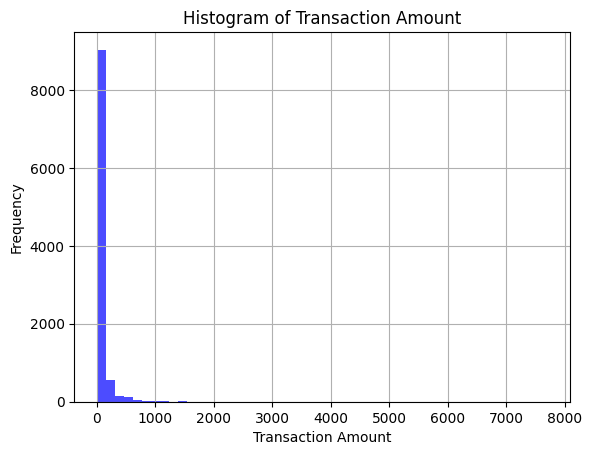

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv('/content/creditcard.csv')

# Plot a histogram of the 'Amount' column
plt.hist(df['Amount'], bins=50, color='blue', alpha=0.7)
plt.xlabel('Transaction Amount')
plt.ylabel('Frequency')
plt.title('Histogram of Transaction Amount')
plt.grid(True)
plt.show()


Correlation


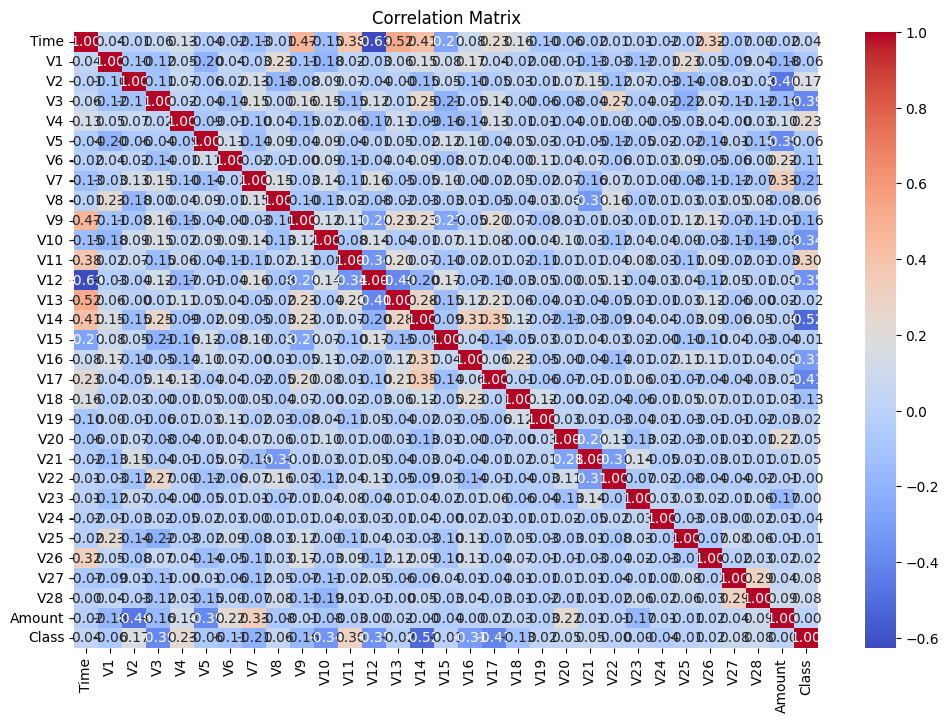

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv('/content/creditcard.csv')

# Compute correlation matrix
correlation_matrix = df.corr()

# Plot the correlation matrix as a heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix')
plt.show()


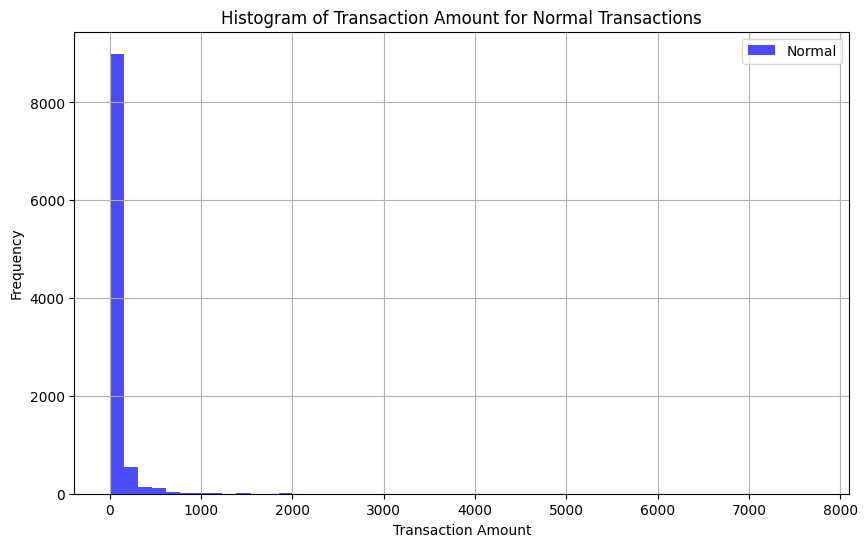

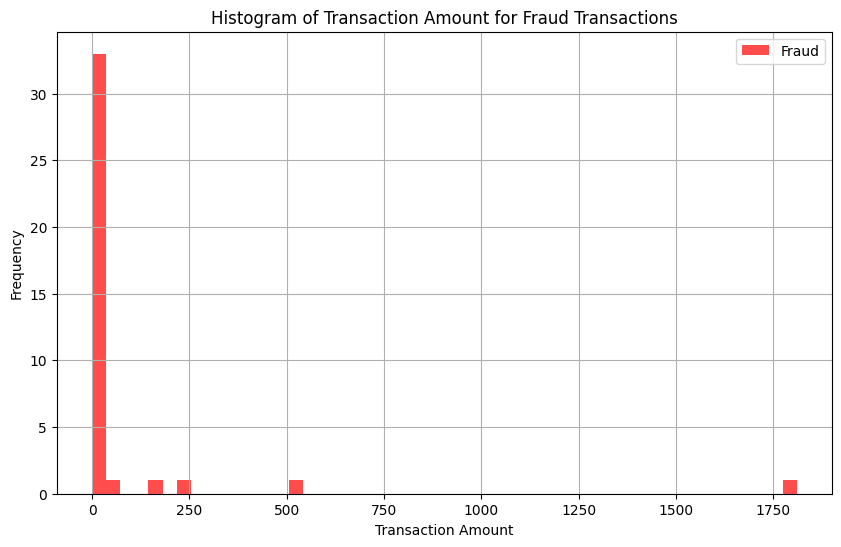

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv('/content/creditcard.csv')

# Separate normal and fraud transactions
normal_transactions = df[df['Class'] == 0]
fraud_transactions = df[df['Class'] == 1]

# Plot histogram for normal transactions
plt.figure(figsize=(10, 6))
plt.hist(normal_transactions['Amount'], bins=50, color='blue', alpha=0.7, label='Normal')
plt.xlabel('Transaction Amount')
plt.ylabel('Frequency')
plt.title('Histogram of Transaction Amount for Normal Transactions')
plt.legend()
plt.grid(True)
plt.show()

# Plot histogram for fraud transactions
plt.figure(figsize=(10, 6))
plt.hist(fraud_transactions['Amount'], bins=50, color='red', alpha=0.7, label='Fraud')
plt.xlabel('Transaction Amount')
plt.ylabel('Frequency')
plt.title('Histogram of Transaction Amount for Fraud Transactions')
plt.legend()
plt.grid(True)
plt.show()


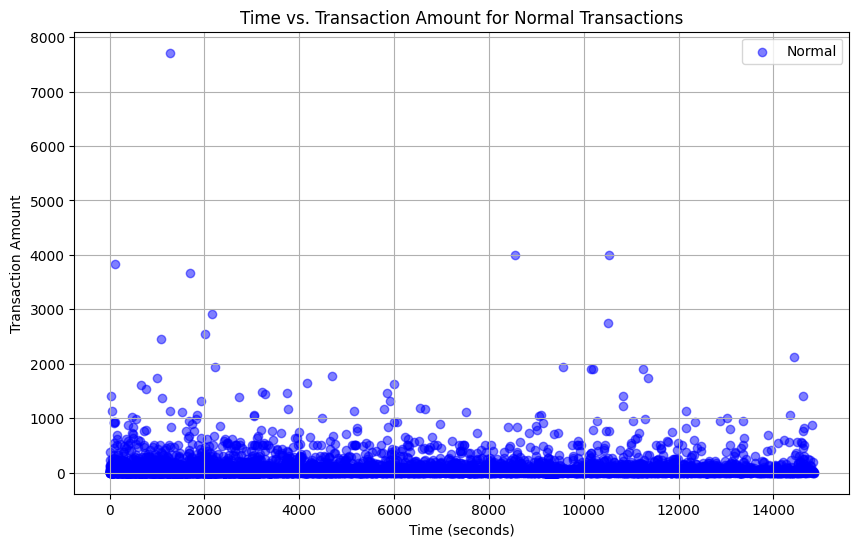

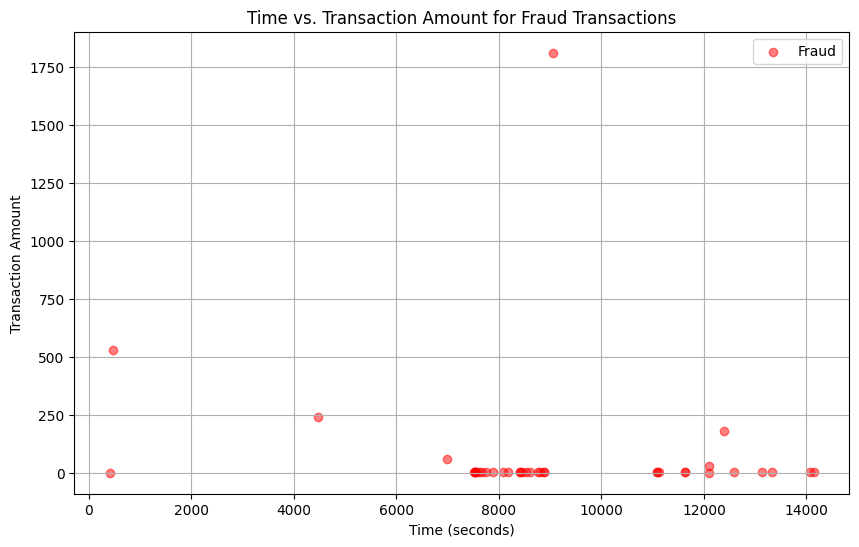

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv('/content/creditcard.csv')

# Separate normal and fraud transactions
normal_transactions = df[df['Class'] == 0]
fraud_transactions = df[df['Class'] == 1]

# Plot time vs. amount for normal transactions
plt.figure(figsize=(10, 6))
plt.scatter(normal_transactions['Time'], normal_transactions['Amount'], color='blue', alpha=0.5, label='Normal')
plt.xlabel('Time (seconds)')
plt.ylabel('Transaction Amount')
plt.title('Time vs. Transaction Amount for Normal Transactions')
plt.legend()
plt.grid(True)
plt.show()

# Plot time vs. amount for fraud transactions
plt.figure(figsize=(10, 6))
plt.scatter(fraud_transactions['Time'], fraud_transactions['Amount'], color='red', alpha=0.5, label='Fraud')
plt.xlabel('Time (seconds)')
plt.ylabel('Transaction Amount')
plt.title('Time vs. Transaction Amount for Fraud Transactions')
plt.legend()
plt.grid(True)
plt.show()


Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9965 entries, 0 to 9964
Data columns (total 31 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Time    9965 non-null   int64  
 1   V1      9965 non-null   float64
 2   V2      9965 non-null   float64
 3   V3      9964 non-null   float64
 4   V4      9964 non-null   float64
 5   V5      9964 non-null   float64
 6   V6      9964 non-null   float64
 7   V7      9964 non-null   float64
 8   V8      9964 non-null   float64
 9   V9      9964 non-null   float64
 10  V10     9964 non-null   float64
 11  V11     9964 non-null   float64
 12  V12     9964 non-null   float64
 13  V13     9964 non-null   float64
 14  V14     9964 non-null   float64
 15  V15     9964 non-null   float64
 16  V16     9964 non-null   float64
 17  V17     9964 non-null   float64
 18  V18     9964 non-null   float64
 19  V19     9964 non-null   float64
 20  V20     9964 non-null   float64
 21  V21     9964 non

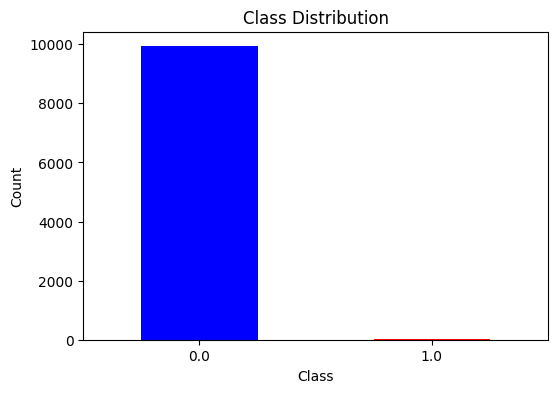

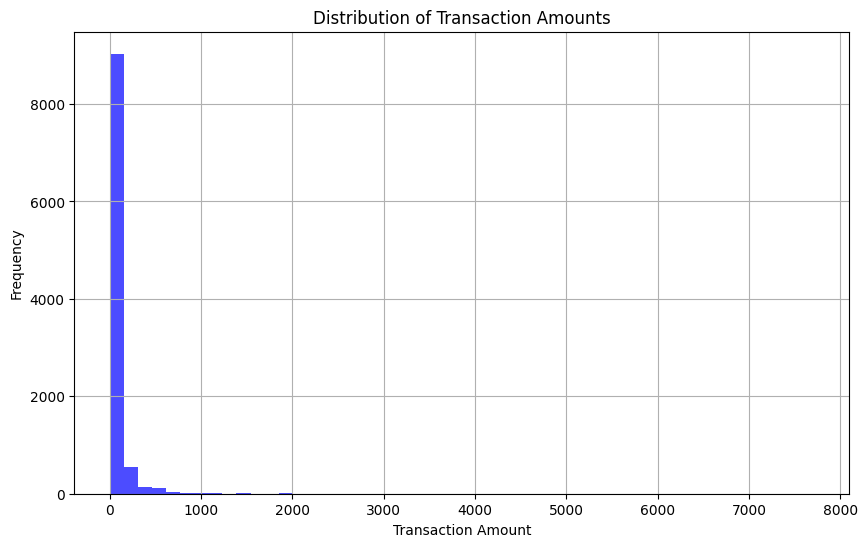

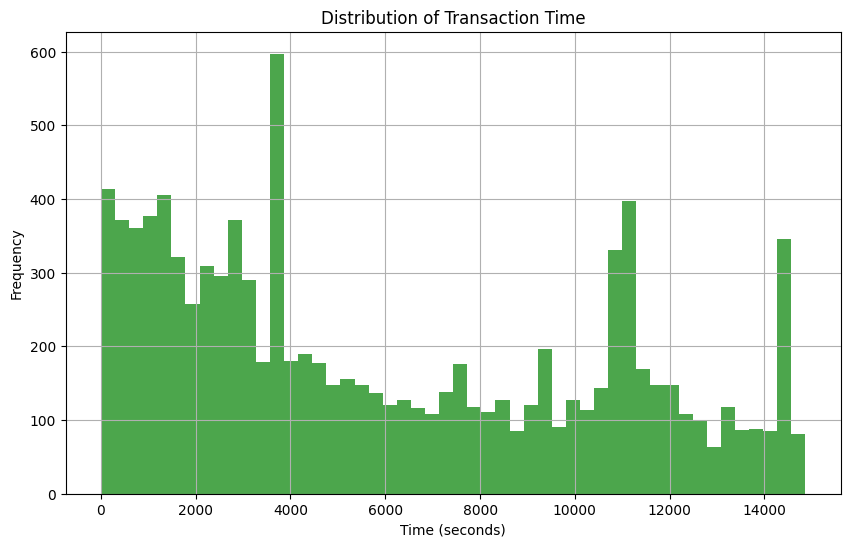


Correlation Matrix:
            Time        V1        V2        V3        V4        V5        V6  \
Time    1.000000  0.040792 -0.005874  0.055810  0.126451 -0.038799 -0.024176   
V1      0.040792  1.000000 -0.097583 -0.122634  0.048162 -0.195993  0.039857   
V2     -0.005874 -0.097583  1.000000 -0.107548  0.072706 -0.061896  0.021591   
V3      0.055810 -0.122634 -0.107548  1.000000  0.018009 -0.044507 -0.137164   
V4      0.126451  0.048162  0.072706  0.018009  1.000000 -0.091227 -0.008598   
V5     -0.038799 -0.195993 -0.061896 -0.044507 -0.091227  1.000000  0.110495   
V6     -0.024176  0.039857  0.021591 -0.137164 -0.008598  0.110495  1.000000   
V7     -0.126318 -0.030488  0.129480  0.153189 -0.101633 -0.139555 -0.019232   
V8     -0.010162  0.230890 -0.177329  0.002749  0.043782  0.091299 -0.014995   
V9      0.471740 -0.112770 -0.082246  0.158881 -0.146422 -0.036638 -0.002147   
V10    -0.146587 -0.184231  0.092632  0.149890  0.022918  0.087296  0.087283   
V11     0.378964  0

In [ ]:
import pandas as pd

# Load the dataset
df = pd.read_csv('/content/creditcard.csv')

# Display basic information about the dataset
print("Dataset Information:")
print(df.info())

# Summary statistics for numerical columns
print("\nSummary Statistics:")
print(df.describe())

# Check for missing values
print("\nMissing Values:")
print(df.isnull().sum())

# Check class distribution
print("\nClass Distribution:")
print(df['Class'].value_counts())

# Visualize class distribution
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
df['Class'].value_counts().plot(kind='bar', color=['blue', 'red'])
plt.title('Class Distribution')
plt.xlabel('Class')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

# Visualize the distribution of transaction amounts
plt.figure(figsize=(10, 6))
plt.hist(df['Amount'], bins=50, color='blue', alpha=0.7)
plt.title('Distribution of Transaction Amounts')
plt.xlabel('Transaction Amount')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

# Visualize the time distribution of transactions
plt.figure(figsize=(10, 6))
plt.hist(df['Time'], bins=50, color='green', alpha=0.7)
plt.title('Distribution of Transaction Time')
plt.xlabel('Time (seconds)')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

# Correlation matrix
correlation_matrix = df.corr()
print("\nCorrelation Matrix:")
print(correlation_matrix)


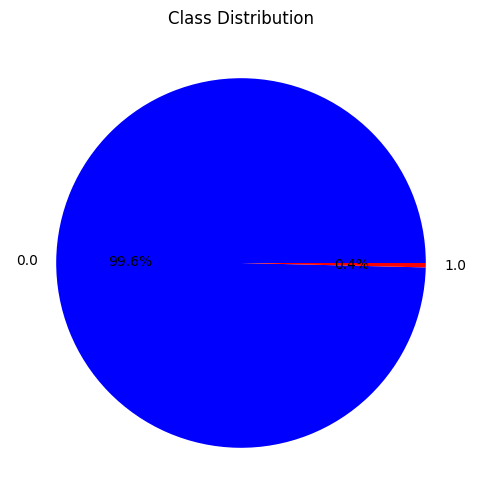

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv('/content/creditcard.csv')

# Compute class distribution
class_distribution = df['Class'].value_counts()

# Plot a pie chart for class distribution
plt.figure(figsize=(6, 6))
plt.pie(class_distribution, labels=class_distribution.index, autopct='%1.1f%%', colors=['blue', 'red'])
plt.title('Class Distribution')
plt.show()


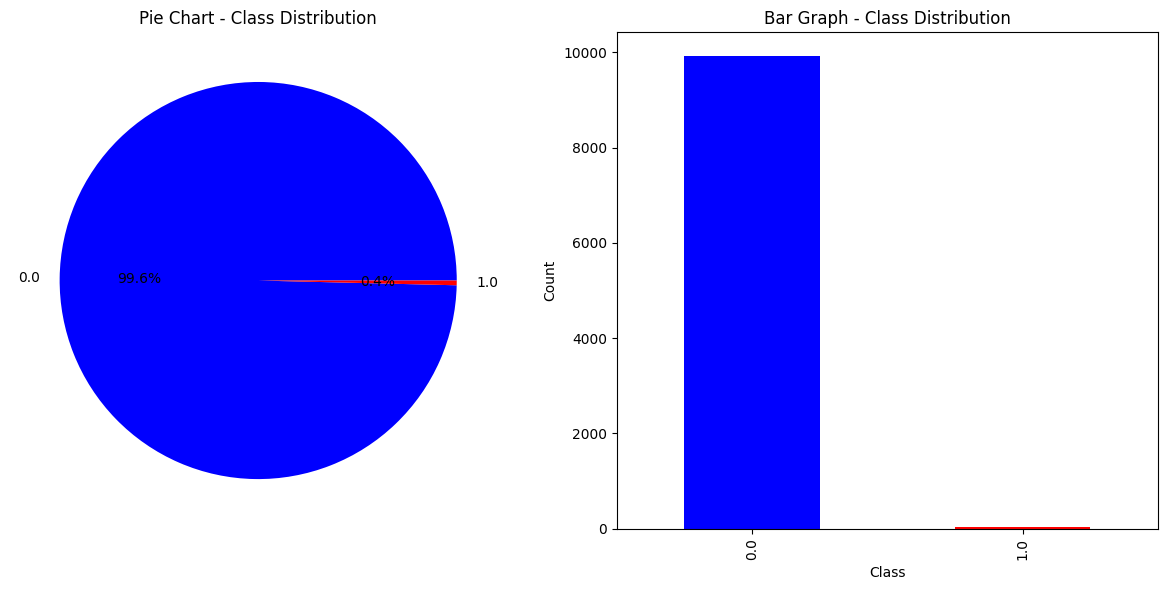

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv('/content/creditcard.csv')

# Compute class distribution
class_distribution = df['Class'].value_counts()

# Plot pie chart for class distribution
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.pie(class_distribution, labels=class_distribution.index, autopct='%1.1f%%', colors=['blue', 'red'])
plt.title('Pie Chart - Class Distribution')

# Plot bar graph for class distribution
plt.subplot(1, 2, 2)
class_distribution.plot(kind='bar', color=['blue', 'red'])
plt.title('Bar Graph - Class Distribution')
plt.xlabel('Class')
plt.ylabel('Count')

plt.tight_layout()
plt.show()


In [ ]:
import sys

In [ ]:
sys.path.append('/content')

In [ ]:
!python test_class_distribution.py

python3: can't open file '/content/test_class_distribution.py': [Errno 2] No such file or directory


unittest

In [ ]:
!pip install unittest
import unittest
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

class TestClassDistribution(unittest.TestCase):
    def setUp(self):
        # Load the dataset
        self.df = pd.read_csv('/content/creditcard.csv')

    def test_load_dataset(self):
        # Test if the dataset is loaded correctly
        self.assertIsNotNone(self.df, "Dataset is not loaded.")
        # You can add more assertions here to check the structure and content of the dataframe

    def test_plot_pie_chart(self):
        # Test if pie chart is plotted correctly
        class_distribution = self.df['Class'].value_counts()
        labels = class_distribution.index
        sizes = class_distribution.values
        colors = ['blue', 'red']

        plt.figure(figsize=(6, 6))
        plt.pie(sizes, labels=labels, autopct='%1.1f%%', colors=colors)
        plt.title('Pie Chart - Class Distribution')

        # Check if the pie chart contains the correct number of wedges
        self.assertEqual(len(plt.gcf().get_axes()[0].patches), len(labels))

        # Check if autopct is properly set
        percentages = [float(label.get_text().strip('%')) for label in plt.gcf().get_axes()[0].texts]
        self.assertTrue(all(np.isclose(percentages, class_distribution / sum(class_distribution) * 100)))

        # Close the plot to prevent displaying in the test environment
        plt.close()

    def test_plot_bar_graph(self):
        # Test if bar graph is plotted correctly
        class_distribution = self.df['Class'].value_counts()

        plt.figure(figsize=(6, 6))
        class_distribution.plot(kind='bar', color=['blue', 'red'])
        plt.title('Bar Graph - Class Distribution')
        plt.xlabel('Class')
        plt.ylabel('Count')

        # Check if the bar graph contains the correct number of bars
        self.assertEqual(len(plt.gcf().get_axes()[0].patches), len(class_distribution))

ERROR: Could not find a version that satisfies the requirement unittest (from versions: none)
ERROR: No matching distribution found for unittest


In [ ]:
unittest.main(exit=False)

E
ERROR: /root/ (unittest.loader._FailedTest)
----------------------------------------------------------------------
AttributeError: module '__main__' has no attribute '/root/'

----------------------------------------------------------------------
Ran 1 test in 0.003s

FAILED (errors=1)


In [ ]:
class TestClassDistribution(unittest.TestCase):
    def setUp(self):
        # Load the dataset
        self.df = pd.read_csv('/content/creditcard.csv')

    def test_load_dataset(self):
        # Test if the dataset is loaded correctly
        self.assertIsNotNone(self.df, "Dataset is not loaded.")
        # You can add more assertions here to check the structure and content of the dataframe

    def test_plot_pie_chart(self):
        # Test if pie chart is plotted correctly
        class_distribution = self.df['Class'].value_counts()
        labels = class_distribution.index
        sizes = class_distribution.values
        colors = ['blue', 'red']

        plt.figure(figsize=(6, 6))
        plt.pie(sizes, labels=labels, autopct='%1.1f%%', colors=colors)
        plt.title('Pie Chart - Class Distribution')

        # Check if the pie chart contains the correct number of wedges
        self.assertEqual(len(plt.gcf().get_axes()[0].patches), len(labels), "Incorrect number of wedges in the pie chart.")

        # Check if autopct is properly set

...E.
ERROR: test_plot_pie_chart (__main__.TestClassDistribution)
----------------------------------------------------------------------
Traceback (most recent call last):
  File "<ipython-input-54-784b17229c4c>", line 33, in test_plot_pie_chart
    self.assertTrue(all(np.isclose(percentages, class_distribution / sum(class_distribution) * 100)))
  File "/usr/local/lib/python3.10/dist-packages/numpy/core/numeric.py", line 2351, in isclose
    return within_tol(x, y, atol, rtol)
  File "/usr/local/lib/python3.10/dist-packages/numpy/core/numeric.py", line 2332, in within_tol
    return less_equal(abs(x-y), atol + rtol * abs(y))
ValueError: operands could not be broadcast together with shapes (4,) (2,) 

----------------------------------------------------------------------
Ran 5 tests in 0.705s

FAILED (errors=1)


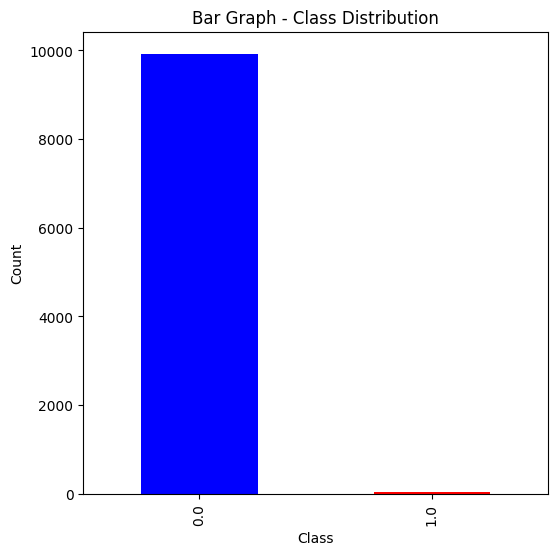

In [ ]:
!pip install pandas matplotlib
import unittest
import pandas as pd
import matplotlib.pyplot as plt

class TestHistogramPlot(unittest.TestCase):
    def test_histogram_plot(self):
        # Load the dataset
        df = pd.read_csv('/content/creditcard.csv')

        # Plot a histogram of the 'Amount' column
        plt.hist(df['Amount'], bins=50, color='blue', alpha=0.7)
        plt.xlabel('Transaction Amount')
        plt.ylabel('Frequency')
        plt.title('Histogram of Transaction Amount')
        plt.grid(True)
        # Save the plot to a file for manual inspection if needed
        plt.savefig('test_histogram.png')
        # Close the plot to prevent displaying in the test environment
        plt.close()

        # Assert that the dataframe is not empty
        self.assertFalse(df.empty, "DataFrame is empty.")
        # Add more assertions as needed to test the plot

if __name__ == '__main__':
    unittest.main(argv=['first-arg-is-ignored'], exit=False)

In [ ]:
!pip install pytest

In [ ]:
@pytest.fixture
def test_data():
    return pd.read_csv('/content/creditcard.csv')

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Fixture to load test data
@pytest.fixture
def test_data():
    return pd.read_csv('/content/creditcard.csv')

def test_data_loading(test_data):
    # Ensure dataset is loaded correctly
    assert not test_data.empty
    # Add more assertions to check dataset structure, columns, etc.

def test_data_processing(test_data):
    # Compute class distribution
    class_distribution = test_data['Class'].value_counts()
    # Ensure class distribution is computed accurately
    assert len(class_distribution) == 2  # Assuming binary classification
    # Add more assertions to check class distribution values, etc.

def test_visualization(test_data):
    # Compute class distribution
    class_distribution = test_data['Class'].value_counts()

    # Plot pie chart for class distribution
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.pie(class_distribution, labels=class_distribution.index, autopct='%1.1f%%', colors=['blue', 'red'])
    plt.title('Pie Chart - Class Distribution')

    # Plot bar graph for class distribution
    plt.subplot(1, 2, 2)
    class_distribution.plot(kind='bar', color=['blue', 'red'])
    plt.title('Bar Graph - Class Distribution')
    plt.xlabel('Class')
    plt.ylabel('Count')

    plt.tight_layout()
    plt.close()  # Close the plot to avoid displaying during testing
    # Add assertions to check properties of the visualizations


In [ ]:
!pip install pytest

In [ ]:
import pytest

In [ ]:
import time
import pandas as pd

def simulate_scalability_test(start_size, end_size, step):
    results = []
    for size in range(start_size, end_size + 1, step):
        start_time = time.time()
        df = pd.DataFrame({'Class': ['A' if i % 2 == 0 else 'B' for i in range(size)]})
        _ = df['Class'].value_counts()  # Simulate data processing
        end_time = time.time()
        processing_time = end_time - start_time
        results.append((size, processing_time))
        print(f"Dataset size: {size}, Processing time: {processing_time:.4f} seconds")
    return zip(*results)

if __name__ == '__main__':
    start_size, end_size, step = 100, 500, 100
    dataset_sizes, processing_times = simulate_scalability_test(start_size, end_size, step)


Dataset size: 100, Processing time: 0.0038 seconds
Dataset size: 200, Processing time: 0.0014 seconds
Dataset size: 300, Processing time: 0.0016 seconds
Dataset size: 400, Processing time: 0.0012 seconds
Dataset size: 500, Processing time: 0.0013 seconds


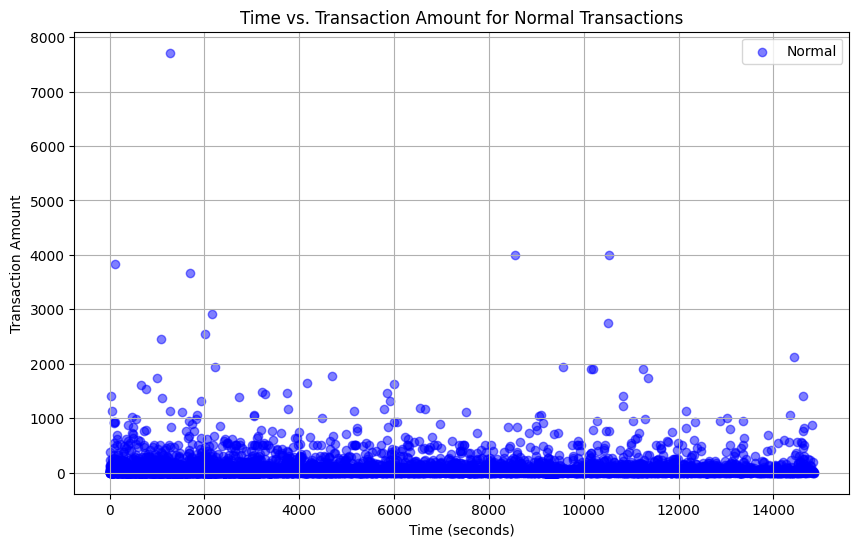

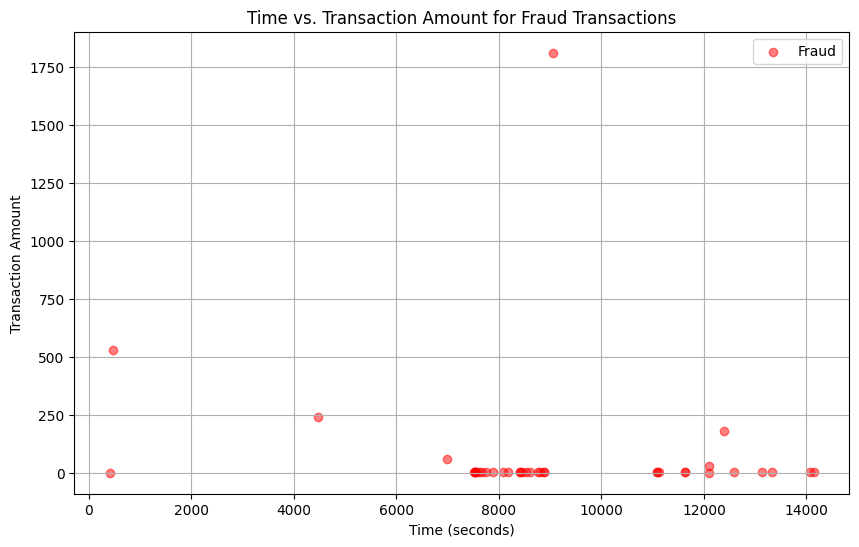

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv('/content/creditcard.csv')

# Separate normal and fraud transactions
normal_transactions = df[df['Class'] == 0]
fraud_transactions = df[df['Class'] == 1]

# Plot time vs. amount for normal transactions
plt.figure(figsize=(10, 6))
plt.scatter(normal_transactions['Time'], normal_transactions['Amount'], color='blue', alpha=0.5, label='Normal')
plt.xlabel('Time (seconds)')
plt.ylabel('Transaction Amount')
plt.title('Time vs. Transaction Amount for Normal Transactions')
plt.legend()
plt.grid(True)
plt.show()

# Plot time vs. amount for fraud transactions
plt.figure(figsize=(10, 6))
plt.scatter(fraud_transactions['Time'], fraud_transactions['Amount'], color='red', alpha=0.5, label='Fraud')
plt.xlabel('Time (seconds)')
plt.ylabel('Transaction Amount')
plt.title('Time vs. Transaction Amount for Fraud Transactions')
plt.legend()
plt.grid(True)
plt.show()
